<a href="https://colab.research.google.com/github/SheKJana/first-own-repository/blob/Bildagumentation/DSCI%20HS25/Bildextraktion_alleFr%C3%BCchteBilder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fruits_baum_split - Agumentationsanpassung**
Ziel: Verwechslungen zwischen verschiedenen Früchten (z. B. Zitrone ↔ Banane extra) reduzieren. In der Validation zeigte sich, dass das Modell teils Sticker + Gelbton als „Shortcut“ lernt statt echte Fruchtmerkmale (Form/Struktur).

Was wurde angepasst (ohne Architektur zu verkomplizieren):

Gezielte Datenaugmentation vor dem CNN:

RandomFlip, RandomRotation(0.15), RandomTranslation(0.05,0.05), RandomZoom(0.10), RandomContrast(0.20)

RandomErasing/Cutout (p=0.4): verdeckt zufällig kleine Bildbereiche → Sticker/Farbflächen sind nicht mehr zuverlässig → Modell muss Form/Struktur lernen.

Leichte Regularisierung im Kopf:

Dropout(0.25) vor der letzten Dense-Phase → weniger Auswendiglernen, stabileres Generalisieren.

CNN-Backbone selbst unverändert (Conv 64→32→16, Dense 128→64, Softmax).

Erwarteter Effekt:

Primär: Weniger Off-Diagonal-Fehler in der Confusion-Matrix zwischen Früchten (v. a. Banane extra vs. Zitrone).

Sekundär: Etwas langsamere, aber stabilere Konvergenz; Validierungs-Accuracy/Loss glatter, weniger Überkonfidenz.

Stellschrauben (bei Bedarf justieren):

RandomErasing p: 0.3–0.5 (höher = stärker gegen Sticker, ggf. etwas konservativer bei p=0.3 starten).

RandomContrast: 0.15–0.25 (zu hoch kann feine Texturen verwischen).

Nur wenn nötig: image_size später von 128 auf 160/192 erhöhen (mehr Strukturdetails, aber teurer).

Messpunkt: Nach dem Training Validierungs- und Test-Confusion-Matrix vergleichen. Erfolg = weniger Frucht-Verwechslungen, Fokus auf Fruchtkörper statt Sticker (optional mit Grad-CAM prüfen).


In [74]:
# ============================================
# BLOCK 1 — Drive mount + Pfade + Imports
# (Quelle: fruits_baum_split/{train,test} + XLSX)
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import os, random, shutil, json, hashlib
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/fruits_baum_split")
TRAIN_DIR = BASE/"train"
TEST_DIR  = BASE/"test"
SPLIT_XLSX = BASE/"train_test_split.xlsx"

assert TRAIN_DIR.exists() and any(TRAIN_DIR.iterdir()), "TRAIN_DIR leer/nicht vorhanden."
assert TEST_DIR.exists()  and any(TEST_DIR.iterdir()),  "TEST_DIR leer/nicht vorhanden."
assert SPLIT_XLSX.exists(), "train_test_split.xlsx nicht gefunden."
print("✅ Struktur gefunden:", BASE)
print("   ↳", TRAIN_DIR)
print("   ↳", TEST_DIR)
print("   ↳", SPLIT_XLSX)


Mounted at /content/drive
✅ Struktur gefunden: /content/drive/MyDrive/fruits_baum_split
   ↳ /content/drive/MyDrive/fruits_baum_split/train
   ↳ /content/drive/MyDrive/fruits_baum_split/test
   ↳ /content/drive/MyDrive/fruits_baum_split/train_test_split.xlsx


In [75]:
# ============================================
# BLOCK 2 — Mapping einlesen (Professor: Dokumentation)
# ============================================

df_split = pd.read_excel(SPLIT_XLSX)
print("🧾 Split-Mapping (Kopf):")
display(df_split.head(8))

print("\nTrain/Test-Verhältnis (aus Mapping):")
display(df_split.groupby(["Klasse","TrainOrTest"]).size().unstack(fill_value=0))


🧾 Split-Mapping (Kopf):


,Dateiname,Pfad,Klasse,TrainOrTest
0,avo_bio_004.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
1,avo_bio_014.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
2,avo_bio_016.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
3,avo_normal_038__test.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
4,avo_normal_039.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
5,avo_normal_040.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
6,avo_normal_041.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
7,avo_normal_042.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test



Train/Test-Verhältnis (aus Mapping):


TrainOrTest,test,train
Klasse,,
avo_bio,3,12
avo_normal,36,39
banane_extra,9,37
banane_normal,2,11
citron_bio,3,12
citron_normal,10,42
mango_extra,5,21
mango_normal,4,16
süssK_bio,3,13


In [76]:
# ============================================
# BLOCK 3 — Klassen-Counts + Duplikat-Check (Name)
# (Professor: saubere Trennung sicherstellen)
# ============================================

def class_counts(root: Path):
    return pd.Series({p.name: len([f for f in p.iterdir() if f.is_file()])
                      for p in sorted(root.iterdir()) if p.is_dir()}).sort_index()

print("📦 Klassenverteilung — TRAIN:")
display(class_counts(TRAIN_DIR))
print("\n📦 Klassenverteilung — TEST:")
display(class_counts(TEST_DIR))

train_names = {f.name for f in TRAIN_DIR.rglob("*/*") if f.is_file()}
test_names  = {f.name for f in TEST_DIR.rglob("*/*") if f.is_file()}
intersect = train_names.intersection(test_names)
print(f"\n🧪 Duplikate (Dateiname) train∩test: {len(intersect)}")
assert len(intersect) == 0, "Dateiname sowohl in train als auch test → bitte Split prüfen."


📦 Klassenverteilung — TRAIN:


,0
avo_bio,12
avo_normal,39
banane_extra,37
banane_normal,11
citron_bio,12
citron_normal,42
mango_extra,21
mango_normal,16
süssK_bio,13
süssK_normal,32



📦 Klassenverteilung — TEST:


,0
avo_bio,3
avo_normal,36
banane_extra,9
banane_normal,2
citron_bio,3
citron_normal,10
mango_extra,5
mango_normal,4
süssK_bio,3
süssK_normal,16



🧪 Duplikate (Dateiname) train∩test: 0


In [77]:
# ============================================
# BLOCK 3b — (Optional) Hash-Check auf echte Inhaltsduplikate
# (Professor macht's nicht explizit; hier ergänzt)
# ============================================

DO_HASH_CHECK = False  # bei Bedarf True setzen (langsamer)

def md5sum(path: Path, chunk=1<<20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while (b := f.read(chunk)):
            h.update(b)
    return h.hexdigest()

if DO_HASH_CHECK:
    def hash_index(root: Path):
        idx = {}
        for f in sorted([p for p in root.rglob("*") if p.is_file()]):
            idx.setdefault(md5sum(f), []).append(f)
        return idx

    train_hash = hash_index(TRAIN_DIR)
    test_hash  = hash_index(TEST_DIR)
    dupe_hashes = set(train_hash).intersection(test_hash)
    print(f"🧪 Duplikate (Inhalt/MD5) train∩test: {len(dupe_hashes)}")
    assert len(dupe_hashes) == 0, "Inhaltsgleiche Dateien in train & test gefunden."


In [78]:
# ============================================
# BLOCK 4 — Datasets laden (Train=80/20 Val, Test separat)
# (Professor-Flow; deine Bildgröße/Batch/Seed)
# ============================================

import tensorflow as tf

image_size = (128, 128)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=seed,
    image_size=image_size, batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=seed,
    image_size=image_size, batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=image_size, batch_size=batch_size
)

class_names = train_ds.class_names
print("🔤 Klassen:", class_names)

# Performance (Cache/Prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100, seed=seed).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Found 235 files belonging to 10 classes.
Using 188 files for training.
Found 235 files belonging to 10 classes.
Using 47 files for validation.
Found 91 files belonging to 10 classes.
🔤 Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


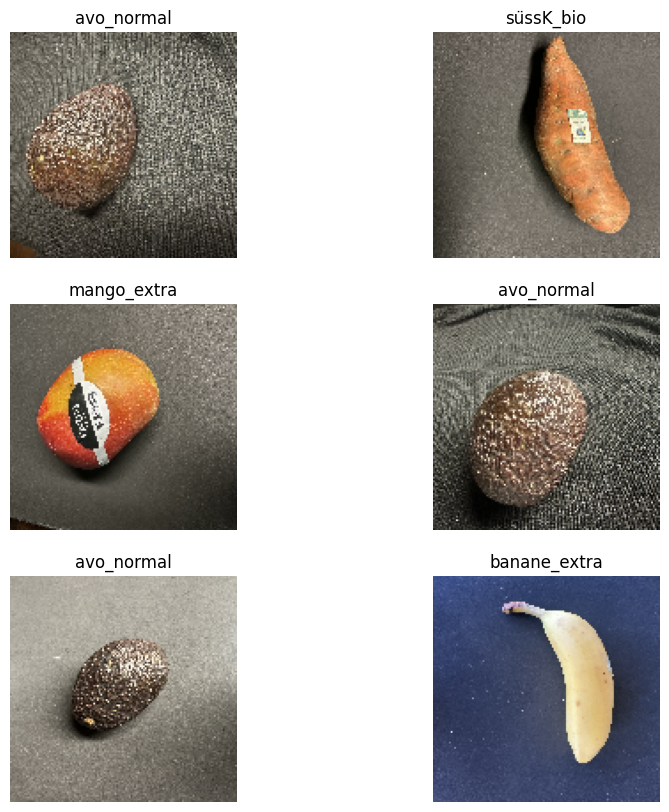

In [79]:
# ============================================
# BLOCK 5 — Sichtprüfung (Sample-Bilder)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [80]:
# ============================================
# BLOCK 6 — Modell (Augmentation gezielt + Dropout)
# ============================================
from tensorflow.keras import layers
import tensorflow as tf

num_classes = len(class_names)
color_image_size = (*image_size, 3)

# Custom-Layer registrieren, damit Speichern/Laden funktioniert
@tf.keras.utils.register_keras_serializable(package="custom", name="RandomErasing")
class RandomErasing(layers.Layer):
    def __init__(self, p=0.4, area_ratio=(0.02, 0.15), aspect_ratio=(0.3, 3.3), **kw):
        super().__init__(**kw)
        self.p = tf.constant(p, dtype=tf.float32)
        self.area_ratio = area_ratio
        self.aspect_ratio = aspect_ratio

    def _erase_once(self, img):
        # img: [H, W, C]
        h = tf.shape(img)[0]; w = tf.shape(img)[1]; c = tf.shape(img)[2]
        area = tf.cast(h * w, tf.float32)

        erase_area = tf.random.uniform([], self.area_ratio[0], self.area_ratio[1]) * area
        aspect     = tf.random.uniform([], self.aspect_ratio[0], self.aspect_ratio[1])

        eh = tf.cast(tf.sqrt(erase_area * aspect), tf.int32)
        ew = tf.cast(tf.sqrt(erase_area / aspect), tf.int32)
        eh = tf.maximum(1, tf.minimum(eh, h))
        ew = tf.maximum(1, tf.minimum(ew, w))

        y1 = tf.random.uniform([], 0, h - eh + 1, dtype=tf.int32)
        x1 = tf.random.uniform([], 0, w - ew + 1, dtype=tf.int32)

        mean = tf.reduce_mean(img, axis=[0, 1], keepdims=True)
        patch = tf.ones([eh, ew, c], dtype=img.dtype)
        paddings = [[y1, h - y1 - eh], [x1, w - x1 - ew], [0, 0]]
        mask = tf.pad(patch, paddings, constant_values=0.0)

        return img * (1.0 - mask) + mean * mask

    def call(self, x, training=None):
        if training is False:
            return x
        def per_image(img):
            do_erase = tf.less(tf.random.uniform([]), self.p)
            return tf.cond(do_erase, lambda: self._erase_once(img), lambda: img)
        return tf.map_fn(per_image, x, fn_output_signature=x.dtype)

def make_model():
    img_inputs = tf.keras.Input(shape=color_image_size, name='Eingabe')

    # 1) Normalisierung
    x = layers.Rescaling(1./255)(img_inputs)

    # 2) Gezielte Augmentations (robust gg. Farbe/Sticker/Position)
    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomTranslation(0.05, 0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.20),
        RandomErasing(p=0.4, area_ratio=(0.02, 0.15)),
    ])
    x = aug(x)

    # 3) CNN-Backbone (wie zuvor)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x); x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='Ausgabe')(x)
    return tf.keras.Model(inputs=img_inputs, outputs=outputs, name='FruitClassifier')

model = make_model()
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Eingabe (InputLayer)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Ausgabe (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,202 (2.13 MB)

 Trainable params: 558,202 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# ============================================
# BLOCK 7 — Kompilieren + Training (robust, kompatibel)
# Fixes:
# - Label Smoothing kompatibel gemacht (Fallback via one-hot + CategoricalCrossentropy)
# - class_weight-Zählung: korrekt über Labels iterieren (kein Unpacking-Fehler)
# ============================================
import tensorflow as tf
from collections import Counter

# --- Loss mit Label Smoothing (kompatibel über TF-Versionen) ---
def make_smooth_loss(num_classes, smoothing=0.05):
    try:
        # Neuere TF-Versionen unterstützen label_smoothing bei Sparse-CE
        _ = tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=smoothing)
        return tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=False, label_smoothing=smoothing
        )
    except TypeError:
        # Fallback: one-hot + CategoricalCrossentropy (gleicher Effekt)
        cce = tf.keras.losses.CategoricalCrossentropy(
            from_logits=False, label_smoothing=smoothing
        )
        def loss_fn(y_true, y_pred):
            y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
            return cce(y_true_oh, y_pred)
        return loss_fn

loss_fn = make_smooth_loss(num_classes=len(class_names), smoothing=0.05)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=25,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5, verbose=1
)

# --- class_weight: inverse Häufigkeit im TRAIN-Split (fairere Gradienten) ---
# WICHTIG: Hier NICHT versuchen "(x, y)" zu entpacken, wenn die Map-Funktion nur y zurückgibt!
y_train_counts = Counter()

# Variante A (einfach & robust): über Batches laufen und Labels als Numpy verarbeiten
for _, yb in train_ds:
    y_np = yb.numpy().astype(int)   # Batch von Label-Indices
    for idx in y_np:
        y_train_counts[int(idx)] += 1

# (Alternative Variante B: unbatch + map nur y, aber EINZEL-VARIABLE!)
# for yb in train_ds.unbatch().map(lambda x, y: y).as_numpy_iterator():
#     y_train_counts[int(yb)] += 1

max_n = max(y_train_counts.values())
class_weight = {i: max_n / y_train_counts.get(i, 1) for i in range(len(class_names))}
print("class_weight:", class_weight)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=120,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight,
    verbose=1
)

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"\n📈 Validation Accuracy: {val_acc:.2%}")


class_weight: {0: 3.1818181818181817, 1: 1.0294117647058822, 2: 1.206896551724138, 3: 5.833333333333333, 4: 5.0, 5: 1.0, 6: 1.8421052631578947, 7: 2.9166666666666665, 8: 2.9166666666666665, 9: 1.5217391304347827}
Epoch 1/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.0712 - loss: 4.2972 - val_accuracy: 0.1064 - val_loss: 2.2831 - learning_rate: 0.0010
Epoch 2/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.1927 - loss: 4.0223 - val_accuracy: 0.1064 - val_loss: 2.2911 - learning_rate: 0.0010
Epoch 3/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2423 - loss: 3.6752 - val_accuracy: 0.2766 - val_loss: 2.2277 - learning_rate: 0.0010
Epoch 4/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2415 - loss: 3.8871 - val_accuracy: 0.2340 - val_loss: 2.1619 - learning_rate: 0.0010
Epoch 5/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2627 - loss: 3.5548 - val_accuracy: 0.2340 - val_loss: 2.1061 - learning_rate: 0.0010
Epoch 6/120
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/

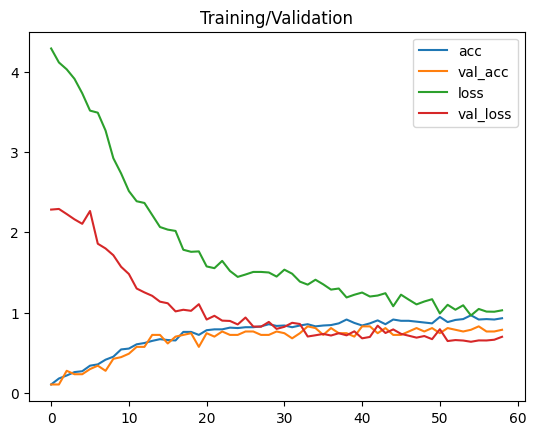

In [82]:
# ============================================
# BLOCK 8 — Trainingskurven
# ============================================

plt.figure()
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training/Validation")
plt.show()


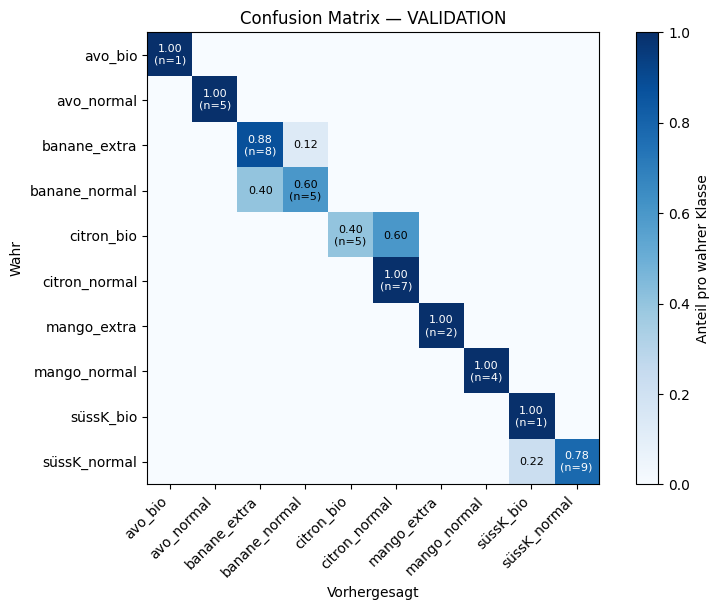


📊 Klassifikationsreport (VALIDATION):
               precision    recall  f1-score   support

      avo_bio       1.00      1.00      1.00         1
   avo_normal       1.00      1.00      1.00         5
 banane_extra       0.78      0.88      0.82         8
banane_normal       0.75      0.60      0.67         5
   citron_bio       1.00      0.40      0.57         5
citron_normal       0.70      1.00      0.82         7
  mango_extra       1.00      1.00      1.00         2
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       0.33      1.00      0.50         1
süssK_normal       1.00      0.78      0.88         9

     accuracy                           0.83        47
    macro avg       0.86      0.87      0.83        47
 weighted avg       0.88      0.83      0.83        47



In [83]:
# ============================================
# BLOCK 9 — Fehleranalyse (VALIDATION)
# Was wird hier gemessen?
# - Datensatz: 20% Validierung aus TRAIN via `validation_split` (subset="validation").
# - Domain: In-domain (gleiche Quelle/Sessions wie Training), NICHT das finale Testset.
# - Aussage: Tuning/Früherkennung von Verwechslungen; tendenziell optimistischer als echter Test.
# ============================================
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Vorhersagen auf Validation sammeln
y_true, y_pred = [], []
for xb, yb in val_ds:
    pr = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy())
    y_pred.extend(np.argmax(pr, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion (zeilen-normalisiert) + Support
cm_val = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
row_sums_v = cm_val.sum(axis=1, keepdims=True).clip(min=1)
cm_val_norm = cm_val / row_sums_v

plt.figure(figsize=(8.5, 6.2))
im = plt.imshow(cm_val_norm, vmin=0, vmax=1, cmap="Blues", aspect='equal')
cb = plt.colorbar(im); cb.set_label("Anteil pro wahrer Klasse", rotation=90)

ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr")
plt.title("Confusion Matrix — VALIDATION")

# Beschriftung: Diagonale immer inkl. n, Off-Diagonale nur >0; Textfarbe nach Intensität
for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        if i == j:
            val = float(cm_val_norm[i, j])
            txt = f"{val:.2f}\n(n={int(row_sums_v[i,0])})"
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
        else:
            if cm_val[i, j] == 0:
                continue
            val = float(cm_val_norm[i, j])
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

print("\n📊 Klassifikationsreport (VALIDATION):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


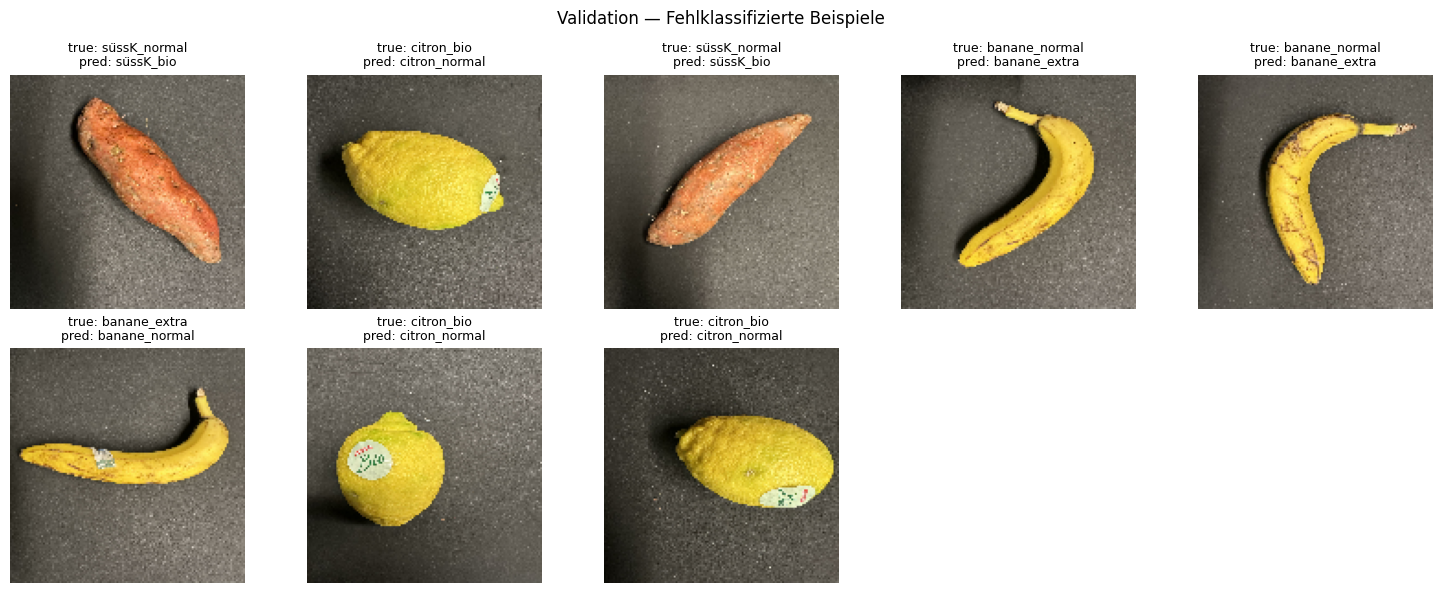

In [84]:
# ============================================
# BLOCK 9b — Fehler-Galerie (VALIDATION): zeige die falsch klassifizierten Val-Bilder
# ============================================
import numpy as np, matplotlib.pyplot as plt

# Vorhersagen + Sammeln der Fehlfälle (wir haben y_true/y_pred aus Block 9)
wrong_imgs, wrong_true, wrong_pred = [], [], []

for xb, yb in val_ds:
    probs = model.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    mism = preds != yb.numpy()
    if np.any(mism):
        wrong_imgs.append(xb.numpy()[mism])
        wrong_true.extend(yb.numpy()[mism])
        wrong_pred.extend(preds[mism])

if wrong_imgs:
    wrong_imgs = np.concatenate(wrong_imgs, axis=0)
    n = len(wrong_imgs)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(wrong_imgs[i].astype("uint8"))
        t = class_names[int(wrong_true[i])]; p = class_names[int(wrong_pred[i])]
        ax.set_title(f"true: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Validation — Fehlklassifizierte Beispiele")
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine Fehlklassifikationen im Validation-Set gefunden.")



✅ TEST Accuracy: 97.80%

📊 Klassifikationsreport (TEST):
               precision    recall  f1-score   support

      avo_bio       1.00      0.67      0.80         3
   avo_normal       0.97      1.00      0.99        36
 banane_extra       0.90      1.00      0.95         9
banane_normal       1.00      0.50      0.67         2
   citron_bio       1.00      1.00      1.00         3
citron_normal       1.00      1.00      1.00        10
  mango_extra       1.00      1.00      1.00         5
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      1.00      1.00         3
süssK_normal       1.00      1.00      1.00        16

     accuracy                           0.98        91
    macro avg       0.99      0.92      0.94        91
 weighted avg       0.98      0.98      0.98        91



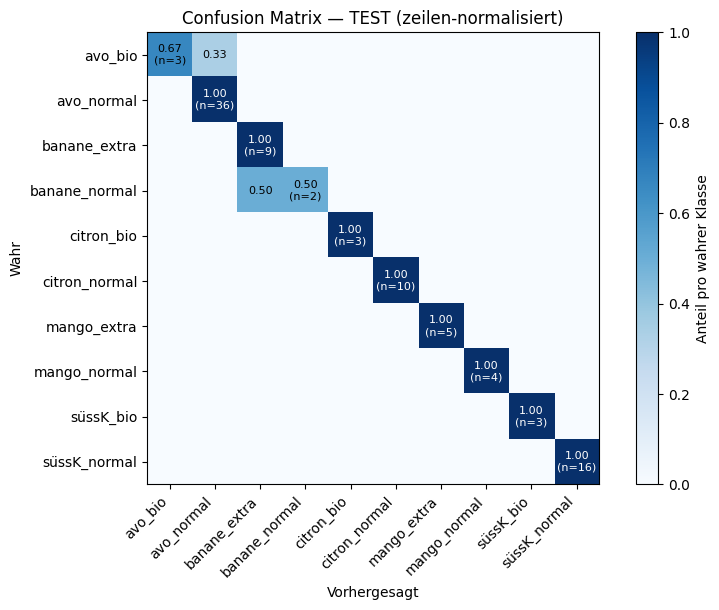

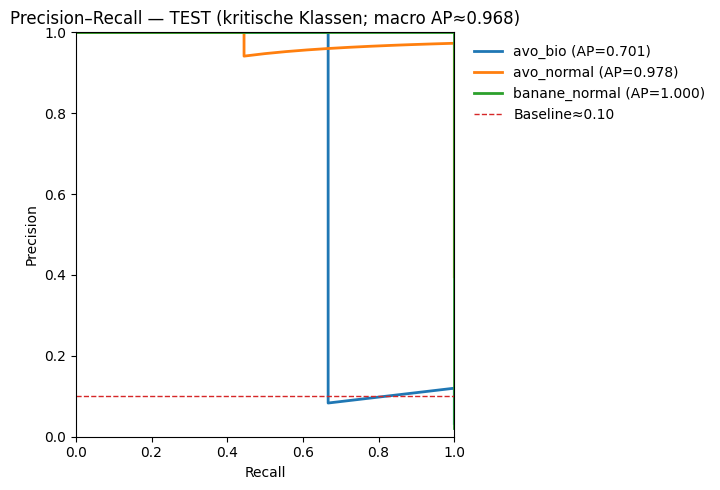

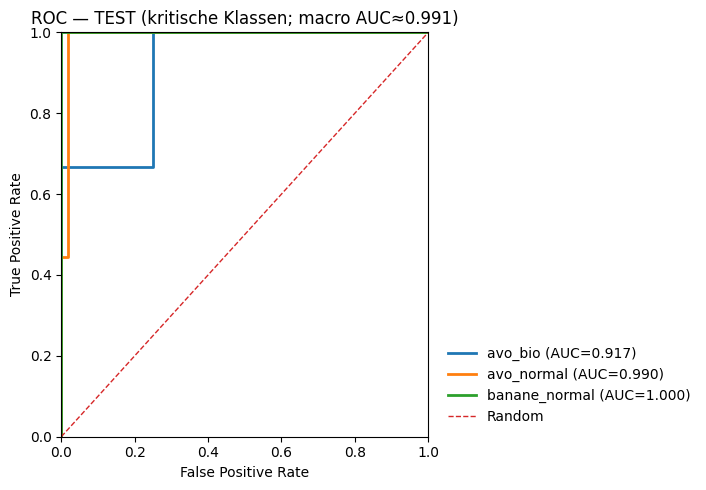

In [85]:
# ============================================
# BLOCK 10 — Finale Test-Evaluation (konsistenter Stil)
# Was wird hier gemessen?
# - Datensatz: Separater TEST-Ordner (physisch getrennt).
# - Domain: Kann sich von TRAIN/VAL unterscheiden (andere Sessions/Belichtungen → Domain-Shift).
# - Aussage: Unabhängige, „ehrliche“ Schätzung der Generalisierung.
# ============================================
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc
)
import numpy as np, matplotlib.pyplot as plt

# 1) Test evaluieren
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ TEST Accuracy: {test_acc:.2%}")

y_true_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob_test = model.predict(test_ds, verbose=0)
y_pred_test = np.argmax(y_prob_test, axis=1)
num_classes = len(class_names)

print("\n📊 Klassifikationsreport (TEST):")
print(classification_report(
    [class_names[i] for i in y_true_test],
    [class_names[i] for i in y_pred_test],
    zero_division=0
))

# 2) Confusion Matrix — zeilen-normalisiert (Blues) + Support
cm = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(num_classes))
row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm / row_sums

plt.figure(figsize=(8.5, 6.2))
im = plt.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues", aspect='equal')
cb = plt.colorbar(im); cb.set_label("Anteil pro wahrer Klasse", rotation=90)

ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr")
plt.title("Confusion Matrix — TEST (zeilen-normalisiert)")

for i in range(num_classes):
    for j in range(num_classes):
        if i == j:
            val = float(cm_norm[i, j])
            txt = f"{val:.2f}\n(n={int(row_sums[i,0])})"
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
        else:
            if cm[i, j] == 0:
                continue
            val = float(cm_norm[i, j])
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

# 3) Precision–Recall — nur kritischste Klassen + Macro-AP
y_true_onehot = np.eye(num_classes)[y_true_test]
recall_per_class = (cm.diagonal() / row_sums.squeeze()).astype(float)
worst_idx = np.argsort(recall_per_class)[:3]   # 3 Klassen mit niedrigstem Recall
keep = set(worst_idx.tolist())

plt.figure(figsize=(7.2, 5.0))
ap_list = []
for i in range(num_classes):
    y_bin = y_true_onehot[:, i]
    p, r, _ = precision_recall_curve(y_bin, y_prob_test[:, i])
    ap = auc(r, p) if len(r) > 1 else 0.0
    ap_list.append(ap)
    if i in keep:
        plt.plot(r, p, lw=2, label=f"{class_names[i]} (AP={ap:.3f})")
macro_ap = float(np.mean(ap_list)) if ap_list else 0.0
baseline = float(y_true_onehot.mean(axis=0).mean())
plt.plot([0,1],[baseline,baseline], '--', lw=1, label=f"Baseline≈{baseline:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision–Recall — TEST (kritische Klassen; macro AP≈{macro_ap:.3f})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()

# 4) ROC — nur kritischste Klassen + Referenzdiagonale
plt.figure(figsize=(7.2, 5.0))
auc_list = []
for i in range(num_classes):
    y_bin = y_true_onehot[:, i]
    fpr, tpr, _ = roc_curve(y_bin, y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)
    if i in keep:
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], '--', lw=1, label="Random")
macro_auc = float(np.mean(auc_list)) if auc_list else 0.0
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — TEST (kritische Klassen; macro AUC≈{macro_auc:.3f})")
plt.legend(bbox_to_anchor=(1.02, 0), loc="lower left", frameon=False)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()


In [86]:
# ============================================
# BLOCK 10b — Wilson-Konfidenzintervalle für Accuracy / Recall
# ============================================
from statsmodels.stats.proportion import proportion_confint
import pandas as pd
import numpy as np

# Gesamt-Accuracy CI
hits = int((y_true_test == y_pred_test).sum())
n    = int(len(y_true_test))
lo, hi = proportion_confint(hits, n, method='wilson')
print(f"🔒 Gesamt-Accuracy: {hits}/{n} = {hits/n:.2%}  (Wilson-CI: {lo:.2%} … {hi:.2%})")

# Klassen-Recall CIs
recall_hits = cm.diagonal().astype(int)
supports    = cm.sum(axis=1).astype(int)

rows = []
for i, c in enumerate(class_names):
    if supports[i] > 0:
        r_lo, r_hi = proportion_confint(recall_hits[i], supports[i], method='wilson')
        rows.append({
            "klasse": c,
            "support": supports[i],
            "recall": recall_hits[i]/supports[i],
            "recall_CI_low": r_lo,
            "recall_CI_high": r_hi
        })
df_ci = pd.DataFrame(rows).sort_values("recall")
print("\n📏 Recall + Wilson-CIs pro Klasse:")
display(df_ci)


🔒 Gesamt-Accuracy: 89/91 = 97.80%  (Wilson-CI: 92.34% … 99.40%)

📏 Recall + Wilson-CIs pro Klasse:


,klasse,support,recall,recall_CI_low,recall_CI_high
3,banane_normal,2,0.500000,0.094531,0.905469
0,avo_bio,3,0.666667,0.207660,0.938508
1,avo_normal,36,1.000000,0.903581,1.000000
2,banane_extra,9,1.000000,0.700855,1.000000
4,citron_bio,3,1.000000,0.438503,1.000000
5,citron_normal,10,1.000000,0.722467,1.000000
6,mango_extra,5,1.000000,0.565518,1.000000
7,mango_normal,4,1.000000,0.510109,1.000000
8,süssK_bio,3,1.000000,0.438503,1.000000
9,süssK_normal,16,1.000000,0.806392,1.000000


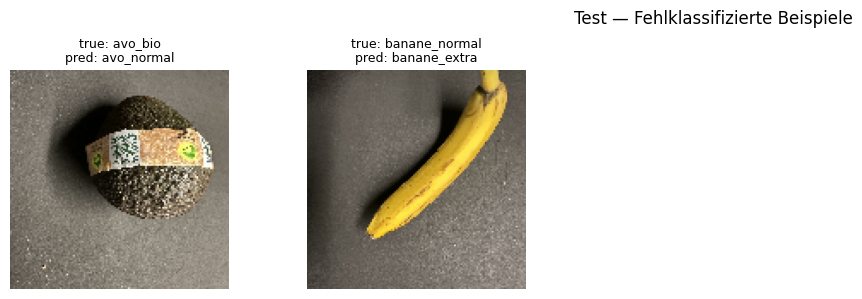

In [87]:
# ============================================
# BLOCK 10e — Fehler-Galerie (TEST): zeige die falsch klassifizierten Test-Bilder
# ============================================
import numpy as np, matplotlib.pyplot as plt

wrong_imgs_t, wrong_true_t, wrong_pred_t = [], [], []

for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    mism = preds != yb.numpy()
    if np.any(mism):
        wrong_imgs_t.append(xb.numpy()[mism])
        wrong_true_t.extend(yb.numpy()[mism])
        wrong_pred_t.extend(preds[mism])

if wrong_imgs_t:
    wrong_imgs_t = np.concatenate(wrong_imgs_t, axis=0)
    n = len(wrong_imgs_t)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(wrong_imgs_t[i].astype("uint8"))
        t = class_names[int(wrong_true_t[i])]; p = class_names[int(wrong_pred_t[i])]
        ax.set_title(f"true: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Test — Fehlklassifizierte Beispiele")
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine Fehlklassifikationen im Test-Set gefunden.")


In [88]:
# ============================================
# BLOCK 11 — Modell + Label-Mapping speichern (Drive)
# (Professor speichert Modell; hier zusätzlich Klassen-JSON)
# ============================================

MODEL_DIR = BASE / "model_out"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

keras_path = MODEL_DIR / "model_fruits.keras"

# 1) Speichern
# Hinweis: Wir speichern normal; beim Laden geben wir custom_objects + compile=False an.
model.save(keras_path)
print("💾 Modell gespeichert:", keras_path)

# 2) Klassen-Labels ablegen (für spätere Zuordnung)
labels_path = MODEL_DIR / "class_names.json"
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump({"class_names": class_names}, f, ensure_ascii=False, indent=2)
print("💾 Klassen gespeichert:", labels_path)

# 3) Reload-Test (robust):
#    - custom_objects: damit Keras deinen registrierten Layer korrekt findet
#    - compile=False: vermeidet Probleme mit Funktions-Loss (wir kompilieren danach erneut)
loaded = tf.keras.models.load_model(
    keras_path,
    custom_objects={"RandomErasing": RandomErasing},
    compile=False
)

# Optional: neu kompilieren, falls du das geladene Modell weiterverwenden willst
# (gleiches Loss wie im Training; falls du den Fallback-Loss nutzt, einfach wiederverwenden)
loaded.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=["accuracy"]
)
print("🔁 Reload OK & neu kompiliert.")


💾 Modell gespeichert: /content/drive/MyDrive/fruits_baum_split/model_out/model_fruits.keras
💾 Klassen gespeichert: /content/drive/MyDrive/fruits_baum_split/model_out/class_names.json
🔁 Reload OK & neu kompiliert.


In [89]:
# ============================================
# BLOCK 12 — (Optional) OOD/Session-Shift Test (falls separater Ordner existiert)
# (Deaktiviert; bei Bedarf Pfad setzen und aktivieren)
# ============================================

RUN_OOD = False
OOD_DIR = Path("/content/drive/MyDrive/banane_extra")  # Beispielpfad

if RUN_OOD:
    assert OOD_DIR.exists(), "OOD-Ordner nicht gefunden."
    img_exts = {".jpg",".jpeg",".png"}
    files = sorted([p for p in OOD_DIR.iterdir() if p.is_file() and p.suffix.lower() in img_exts])
    if not files:
        raise RuntimeError("Keine OOD-Bilder gefunden.")

    def load_and_preprocess(path):
        img_b = tf.io.read_file(path)
        img = tf.image.decode_image(img_b, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        return tf.cast(img, tf.float32)

    paths = [str(p) for p in files]
    ood_ds = tf.data.Dataset.from_tensor_slices(paths).map(load_and_preprocess).batch(batch_size)
    probs = model.predict(ood_ds, verbose=0)
    preds = np.argmax(probs, axis=1)

    target = "banane_extra"
    if target in class_names:
        tidx = class_names.index(target)
        hits = int(np.sum(preds == tidx))
        n = len(preds)
        print(f"🍌 OOD '{target}': {hits}/{n} ({hits/n:.1%})")
    else:
        print("⚠️ Zielklasse für OOD nicht in class_names:", class_names)
